####  This code provides an interactive tool to segment an image based on color. Using the trackbars to adjust the HSV range until we isolate the desired color region in the image.

In [2]:
import cv2
import numpy as np

# Load the image
image = cv2.imread('img2/plant_image10.jpg')  # Replace with your image path
image = cv2.resize(image, (600, 400))  # Resize for better visualization
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Function to update mask based on trackbar values
def update_mask(val):
    lower_h = cv2.getTrackbarPos('Lower H', 'HSV Adjustments')
    lower_s = cv2.getTrackbarPos('Lower S', 'HSV Adjustments')
    lower_v = cv2.getTrackbarPos('Lower V', 'HSV Adjustments')
    upper_h = cv2.getTrackbarPos('Upper H', 'HSV Adjustments')
    upper_s = cv2.getTrackbarPos('Upper S', 'HSV Adjustments')
    upper_v = cv2.getTrackbarPos('Upper V', 'HSV Adjustments')

    # Define lower and upper HSV values
    lower_bound = np.array([lower_h, lower_s, lower_v])
    upper_bound = np.array([upper_h, upper_s, upper_v])

    # Apply mask
    mask = cv2.inRange(hsv, lower_bound, upper_bound)
    result = cv2.bitwise_and(image, image, mask=mask)

    # Display results
    cv2.imshow('Masked Image', mask)
    cv2.imshow('Segmented Image', result)

# Create a window
cv2.namedWindow('HSV Adjustments')

# Create trackbars for HSV adjustments
cv2.createTrackbar('Lower H', 'HSV Adjustments', 25, 179, lambda x: None)
cv2.createTrackbar('Lower S', 'HSV Adjustments', 40, 255, lambda x: None)
cv2.createTrackbar('Lower V', 'HSV Adjustments', 40, 255, lambda x: None)
cv2.createTrackbar('Upper H', 'HSV Adjustments', 90, 179, lambda x: None)
cv2.createTrackbar('Upper S', 'HSV Adjustments', 255, 255, lambda x: None)
cv2.createTrackbar('Upper V', 'HSV Adjustments', 255, 255, lambda x: None)

# Loop to keep the trackbar window running
while True:
    update_mask(0)  # Update the mask dynamically
    key = cv2.waitKey(1) & 0xFF
    if key == 27:  # Press 'Esc' to exit
        break

cv2.destroyAllWindows()


In [3]:
import cv2
import numpy as np

def process_and_save_green_mask(image_path, output_mask_path, output_masked_image_path):
    """
    Processes an image to create a green mask, saves the mask as a grayscale image,
    and also saves the original image with only the green areas displayed.

    Args:
        image_path (str): Path to the input image.
        output_mask_path (str): Path to save the grayscale mask image.
        output_masked_image_path (str): Path to save the color image with only green areas.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define HSV range for green color (adjust if needed)
    lower_green = np.array([21, 78, 83])  # Lower HSV threshold
    upper_green = np.array([50, 255, 223])  # Upper HSV threshold

    # Create mask for green areas (plant)
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Apply morphological operations to clean the mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Save the grayscale mask
    cv2.imwrite(output_mask_path, mask)
    print(f"Mask saved to: {output_mask_path}")

    # Apply the mask to the original image to isolate green areas
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Save the masked color image
    cv2.imwrite(output_masked_image_path, masked_img)
    print(f"Masked image saved to: {output_masked_image_path}")

# Example usage:
image_path = "img2/plant_image10.jpg"  # Replace with your image path
output_mask_path = "img2/green_mask.jpg"
output_masked_image_path = "img2/green_masked_image.jpg"


process_and_save_green_mask(image_path, output_mask_path, output_masked_image_path)

Mask saved to: img2/green_mask.jpg
Masked image saved to: img2/green_masked_image.jpg


When extracting the plant from the image, the plant and other green objects in the image were also retained.


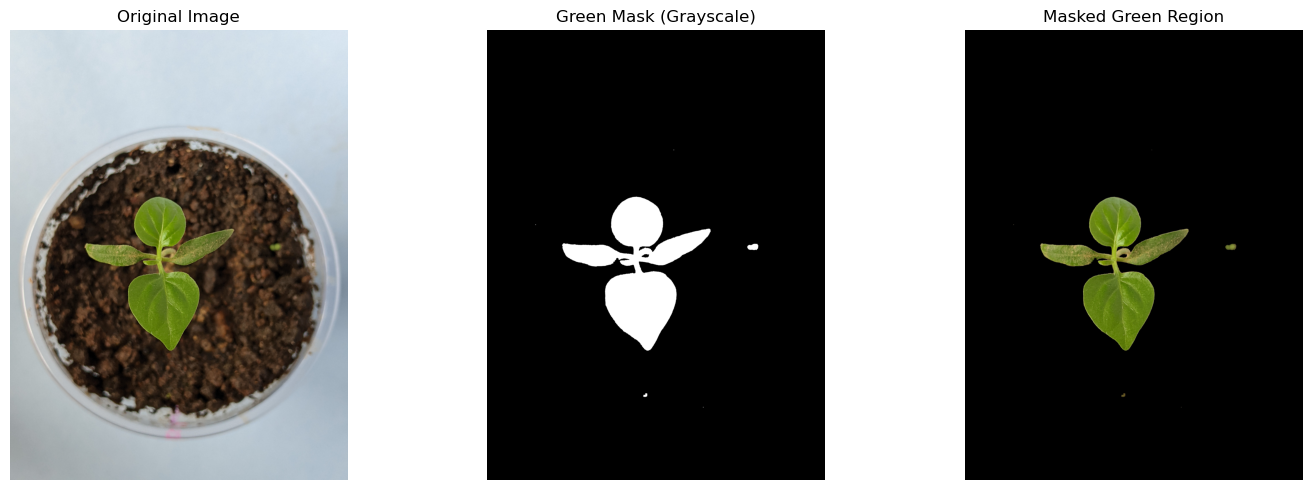

In [4]:
import cv2
import matplotlib.pyplot as plt

# Paths to the processed images
image_path = "img2/plant_image10.jpg"
output_mask_path = "img2/green_mask.jpg"
output_masked_image_path = "img2/green_masked_image.jpg"

# Read the images
img = cv2.imread(image_path)
mask = cv2.imread(output_mask_path, cv2.IMREAD_GRAYSCALE)
masked_img = cv2.imread(output_masked_image_path)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
masked_img_rgb = cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB)

# Plot using matplotlib
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Green Mask (Grayscale)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_img_rgb)
plt.title("Masked Green Region")
plt.axis('off')

plt.tight_layout()
plt.show()


#### From this all regions palant is the largest green region in here
so we remove all other regions accepting that largest region

In [5]:
import cv2
import numpy as np

def process_and_save_green_mask(image_path, output_mask_path, output_masked_image_path):
    """
    Processes an image to create a green mask, keeps only the largest green region,
    applies morphological operations to enhance it, saves the mask as a grayscale image,
    and also saves the original image with only the green areas displayed.

    Args:
        image_path (str): Path to the input image.
        output_mask_path (str): Path to save the grayscale mask image.
        output_masked_image_path (str): Path to save the color image with only green areas.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define HSV range for green color (adjust if needed)
    lower_green = np.array([21, 78, 83])  # Lower HSV threshold
    upper_green = np.array([50, 255, 223])  # Upper HSV threshold

    # Create mask for green areas (plant)
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Apply morphological operations to clean the mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Find the largest contour
        largest_contour = max(contours, key=cv2.contourArea)

        # Create a blank mask to draw the largest contour
        largest_mask = np.zeros_like(mask)
        cv2.drawContours(largest_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    else:
        print("No green region detected.")
        return

    # Apply morphological operations again to enhance the mask
    largest_mask = cv2.morphologyEx(largest_mask, cv2.MORPH_OPEN, kernel)
    largest_mask = cv2.morphologyEx(largest_mask, cv2.MORPH_CLOSE, kernel)

    # Save the grayscale mask
    cv2.imwrite(output_mask_path, largest_mask)
    print(f"Largest green region mask saved to: {output_mask_path}")

    # Apply the mask to the original image to isolate the largest green area
    masked_img = cv2.bitwise_and(img, img, mask=largest_mask)

    # Save the masked color image
    cv2.imwrite(output_masked_image_path, masked_img)
    print(f"Masked image saved to: {output_masked_image_path}")

# Example usage:
image_path = "img2/plant_image10.jpg"  # Replace with your image path
output_mask_path = "img2/largest_green_mask.jpg"
output_masked_image_path = "img2/largest_green_masked_image.jpg"

process_and_save_green_mask(image_path, output_mask_path, output_masked_image_path)


Largest green region mask saved to: img2/largest_green_mask.jpg
Masked image saved to: img2/largest_green_masked_image.jpg


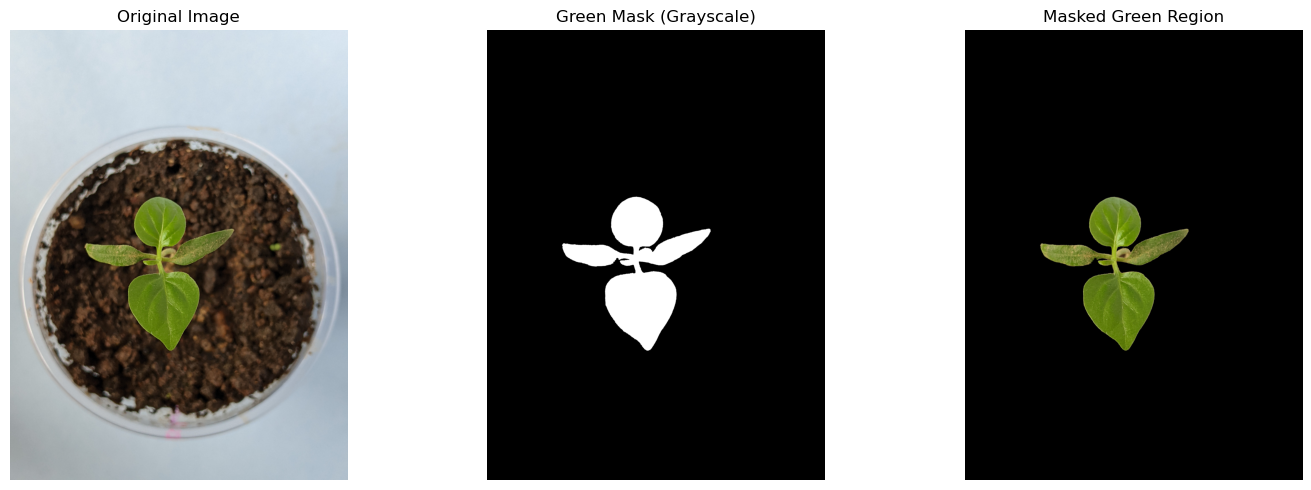

In [6]:
import cv2
import matplotlib.pyplot as plt

# Paths to the processed images
image_path = "img2/plant_image10.jpg"
output_mask_path = "img2/largest_green_mask.jpg"
output_masked_image_path = "img2/largest_green_masked_image.jpg"

# Read the images
img = cv2.imread(image_path)
mask = cv2.imread(output_mask_path, cv2.IMREAD_GRAYSCALE)
masked_img = cv2.imread(output_masked_image_path)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
masked_img_rgb = cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB)

# Plot using matplotlib
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Green Mask (Grayscale)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_img_rgb)
plt.title("Masked Green Region")
plt.axis('off')

plt.tight_layout()
plt.show()
